In [1]:
import pandas as pd

file_path = r"D:\projects\project_pashupatastra\data\network\NF-BoT-IoT-v3\data\NF-BoT-IoT-v3.csv"

# Read 100,000 rows at a time
chunk_size = 100_000
chunks = []

for chunk in pd.read_csv(file_path, chunksize=100_000):
    sample = chunk.sample(frac=0.1, random_state=42)  # use 10% data
    chunks.append(sample)


df = pd.concat(chunks, ignore_index=True)
print("Loaded:", df.shape)


Loaded: (1693381, 55)


In [2]:
import numpy as np
import pandas as pd

# Replace inf/-inf with NaN, then drop them
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(exclude=['object']).columns

print("Categorical columns:", list(categorical_cols))
print("Numerical columns:", list(numerical_cols))


Categorical columns: ['IPV4_SRC_ADDR', 'IPV4_DST_ADDR', 'Attack']
Numerical columns: ['FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS', 'L4_SRC_PORT', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT', 'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN', 'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES', 'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS', 'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS', 'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT', 'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES', 'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES', 'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT', 'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_ID', 'DNS_QUERY_TYPE', 'DNS_TTL_ANSWER', 'FTP_COMMAND_RET_CODE', 'SRC_TO_DST_IAT_MIN', 'SRC_TO_DST_IAT_MA

In [3]:
df.head(20)

,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,...,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack
0,1528095878919,1528095895609,192.168.100.147,62893,192.168.100.3,80,6,7.0,280,2,...,16689,16689,16689,0,0,0,0,0,1,DDoS
1,1528095880044,1528095896982,192.168.100.147,1790,192.168.100.3,80,6,7.0,320,3,...,322,16614,8468,8145,0,0,0,0,1,DDoS
2,1528103299785,1528103299829,192.168.100.7,80,192.168.100.149,46590,6,7.0,52,1,...,0,0,0,0,0,0,0,0,1,DDoS
3,1528095879172,1528095895888,192.168.100.147,63912,192.168.100.3,80,6,7.0,320,3,...,279,16436,8357,8078,0,0,0,0,1,DDoS
4,1528097076662,1528097128446,192.168.100.148,60168,192.168.100.6,80,6,7.0,560,4,...,16977,17532,17247,226,51742,51742,51742,0,1,DDoS
5,1528095879102,1528095895764,192.168.100.147,63572,192.168.100.3,80,6,7.0,280,2,...,16662,16662,16662,0,0,0,0,0,1,DDoS
6,1528095885912,1528095900358,192.168.100.150,12603,192.168.100.3,80,6,7.0,420,3,...,4958,9488,7223,2264,0,0,0,0,1,DDoS
7,1528095885067,1528095900099,192.168.100.150,9477,192.168.100.3,80,6,7.0,460,4,...,226,9932,5010,3963,0,0,0,0,1,DDoS
8,1528097867232,1528097872779,192.168.100.150,1576,192.168.100.7,80,6,7.0,280,2,...,5547,5547,5547,0,0,0,0,0,1,DDoS
9,1528096098740,1528096116812,192.168.100.148,46857,192.168.100.3,80,6,7.0,700,5,...,3277,8066,4517,2049,0,0,0,0,1,DDoS


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score, precision_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

warnings.filterwarnings("ignore")



In [3]:
# =====================================================
# 1. Load the Dataset
# =====================================================
file_path = r"D:\projects\project_pashupatastra\data\network\NF-BoT-IoT-v3\data\NF-BoT-IoT-v3.csv"

chunk_size = 100_000
chunks = []

for chunk in pd.read_csv(file_path, chunksize=chunk_size):
    sample = chunk.sample(frac=0.05, random_state=42)  # 5% sample for memory safety
    chunks.append(sample)

df = pd.concat(chunks, ignore_index=True)
print("✅ Loaded:", df.shape)



✅ Loaded: (846690, 55)


In [4]:
# =====================================================
# 2. Basic Cleaning
# =====================================================
df.dropna(inplace=True)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)



In [5]:
# =====================================================
# 3. Encode Categorical Columns
# =====================================================
cat_cols = ['IPV4_SRC_ADDR', 'IPV4_DST_ADDR', 'Attack']
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le  



In [6]:
# =====================================================
# 4. Define Features and Labels
# =====================================================
X = df.drop(['Label', 'Attack'], axis=1)
y = df['Attack']  # multiclass target



In [7]:
# =====================================================
# 5. Normalize Numerical Features
# =====================================================
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)



In [8]:
# =====================================================
# 6. Train-Test Split
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)



In [9]:
# =====================================================
# 7. Reshape for LSTM Input (samples, timesteps, features)
# =====================================================
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))



In [10]:
# =====================================================
# 8. One-Hot Encode Labels
# =====================================================
num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)



In [11]:
# =====================================================
# 9. Build LSTM Model
# =====================================================
model = Sequential([
    LSTM(128, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 1, 128)         │        93,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 147,077 (574.52 KB)

 Trainable params: 147,077 (574.52 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# =====================================================
# 10. Train Model
# =====================================================
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=10,
    batch_size=256,
    verbose=1
)



Epoch 1/10
2482/2482 ━━━━━━━━━━━━━━━━━━━━ 34s 12ms/step - accuracy: 0.7533 - loss: 0.5240 - val_accuracy: 0.8984 - val_loss: 0.2333
Epoch 2/10
2482/2482 ━━━━━━━━━━━━━━━━━━━━ 86s 34ms/step - accuracy: 0.9004 - loss: 0.2394 - val_accuracy: 0.9220 - val_loss: 0.1919
Epoch 3/10
2482/2482 ━━━━━━━━━━━━━━━━━━━━ 92s 37ms/step - accuracy: 0.9192 - loss: 0.1990 - val_accuracy: 0.9387 - val_loss: 0.1529
Epoch 4/10
2482/2482 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - accuracy: 0.9332 - loss: 0.1679 - val_accuracy: 0.9446 - val_loss: 0.1339
Epoch 5/10
2482/2482 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - accuracy: 0.9384 - loss: 0.1529 - val_accuracy: 0.9479 - val_loss: 0.1230
Epoch 6/10
2482/2482 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - accuracy: 0.9417 - loss: 0.1440 - val_accuracy: 0.9516 - val_loss: 0.1151
Epoch 7/10
2482/2482 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - accuracy: 0.9450 - loss: 0.1347 - val_accuracy: 0.9562 - val_loss: 0.1052
Epoch 8/10
2482/2482 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - accuracy: 0.9475 -

In [13]:
# =====================================================
# 11. Evaluate
# =====================================================
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

acc = accuracy_score(y_test, y_pred_classes)
precision = precision_score(y_test, y_pred_classes, average='weighted')
recall = recall_score(y_test, y_pred_classes, average='weighted')
f1 = f1_score(y_test, y_pred_classes, average='weighted')

print(f"\n✅ LSTM Accuracy: {acc*100:.2f}%")
print(f"✅ Precision: {precision*100:.2f}%")
print(f"✅ Recall: {recall*100:.2f}%")
print(f"✅ F1-Score: {f1*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes))



4964/4964 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step

✅ LSTM Accuracy: 96.37%
✅ Precision: 96.37%
✅ Recall: 96.37%
✅ F1-Score: 96.37%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.74      0.85       186
           1       0.97      0.95      0.96     70597
           2       0.96      0.97      0.96     78069
           3       1.00      1.00      1.00      9986
           4       0.00      0.00      0.00         3

    accuracy                           0.96    158841
   macro avg       0.78      0.73      0.75    158841
weighted avg       0.96      0.96      0.96    158841



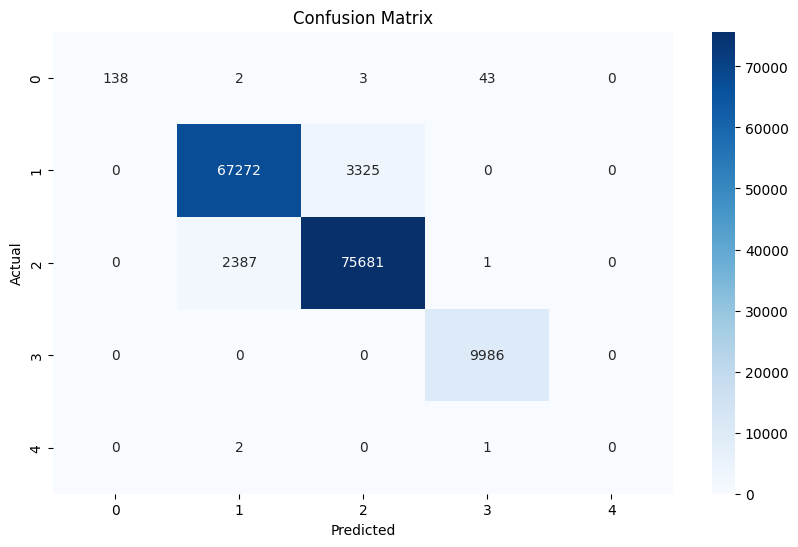

In [14]:
# =====================================================
# 12. Confusion Matrix
# =====================================================
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()



In [15]:
# =====================================================
# 13. Save Model, Scaler, and Label Encoders
# =====================================================
model.save(r"D:\projects\project_pashupatastra\models\nids_lstm_model.h5")
joblib.dump(scaler, r"D:\projects\project_pashupatastra\models\nids_scaler.pkl")

for col, enc in encoders.items():
    joblib.dump(enc, rf"D:\projects\project_pashupatastra\models\{col}_encoder.pkl")

print("✅ Model, scaler, and encoders saved successfully!")


✅ Model, scaler, and encoders saved successfully!
